In [5]:
import pandas as pd 
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adagrad, SGD

In [6]:

df = pd.read_csv(r"C:\Users\KOIN\Downloads\titanic (1).csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [7]:
df = df.drop(["Name" , "Ticket" , "Cabin"] , axis=1)

df["Age"].fillna(df["Age"].mean() , inplace=True)

df["Fare"].fillna(df["Fare"].median() , inplace=True)

df["Embarked"].fillna(df["Embarked"].mode() , inplace=True)

df = pd.get_dummies(df , columns=["Sex"  , "Embarked"] , drop_first=True)


C:\Users\KOIN\AppData\Local\Temp\ipykernel_19420\692352329.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].mean() , inplace=True)
C:\Users\KOIN\AppData\Local\Temp\ipykernel_19420\692352329.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

In [11]:
x = df.drop(columns=["Survived"], axis=1)
y = df["Survived"]


x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)


In [16]:
def create_model():

    model = Sequential()
    model.add(Dense(32 , input_dim=x_train.shape[1] , activation="relu"))
    model.add(Dense(16 , activation="relu"))
    model.add(Dense(1 , activation="sigmoid"))

    return model

In [19]:
adagard_model = create_model()
adagard_opt = Adagrad(learning_rate=0.01)

adagard_model.compile( optimizer= adagard_opt , loss = "binary_crossentropy" , metrics=["accuracy"])

adagard_his = adagard_model.fit(x_train , y_train , validation_data=(x_train , y_train) , epochs=100 , batch_size=32 , verbose=0 )

In [20]:
nag_model = create_model()

nag_opt = SGD(learning_rate=0.01)

nag_model.compile(optimizer= nag_opt , loss= "binary_crossentropy" , metrics=["accuracy"])

nag_his = nag_model.fit(x_train , y_train  , validation_data=(x_train , y_train ) , epochs= 100 , batch_size=32 , verbose=0)

In [22]:
moment_model = create_model()

moment_opt = SGD(learning_rate=0.01)

moment_model.compile(optimizer= moment_opt ,  loss= "binary_crossentropy" , metrics =["accuracy"])

moment_his = moment_model.fit(x_train , y_train , validation_data=(x_train , y_train ) , epochs=100 , batch_size= 32 , verbose= 0 )

In [25]:
import matplotlib.pyplot as plt 

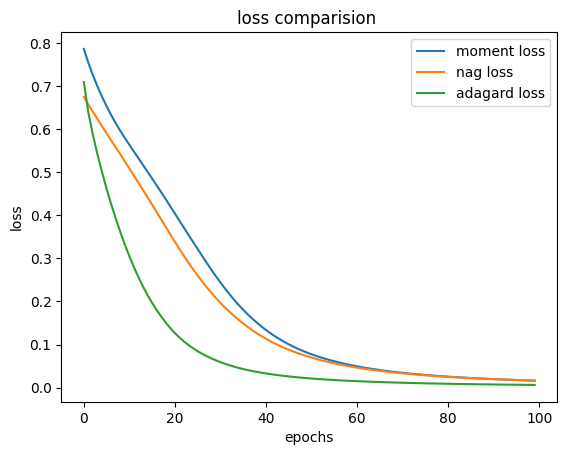

In [29]:
plt.plot(moment_his.history["loss"] , label=["moment loss"])
plt.plot(nag_his.history["loss"] , label=["nag loss"])
plt.plot(adagard_his.history["loss"] , label="adagard loss")

plt.title("loss comparision ")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

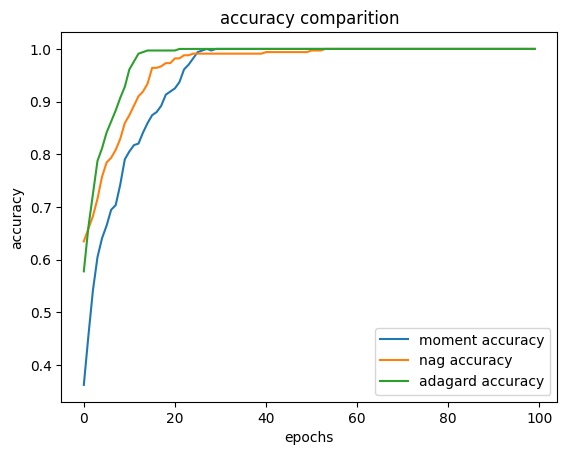

In [31]:
plt.plot(moment_his.history["accuracy"] , label=["moment accuracy"])
plt.plot(nag_his.history["accuracy"] , label=["nag accuracy"])
plt.plot(adagard_his.history["accuracy"] , label=["adagard accuracy"])

plt.title("accuracy comparition")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()